In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.models.efficientnet import EfficientNet_B0_Weights
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
import os

# Set device (use GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [7]:
import os
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

# Data transforms
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load full dataset (check if path exists and has proper structure)
dataset_path = '/home/rifat-cou/Documents/Project/Dataset_Raw'  # e.g., folder with subfolders for each class

# Check if path exists
if not os.path.exists(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' does not exist")
else:
    # Check if path has class subdirectories with images
    subdirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
    if not subdirs:
        print(f"Error: No class subdirectories found in '{dataset_path}'")
        print("ImageFolder expects a directory structure like: dataset_path/class_name/image_files")
    else:
        print(f"Found {len(subdirs)} potential class directories: {subdirs}")
        
        # Try to load the dataset
        try:
            full_dataset = datasets.ImageFolder(dataset_path, transform=train_transform)
            
            # Split into train/val (80/20) if no separate folders
            train_size = int(0.8 * len(full_dataset))
            val_size = len(full_dataset) - train_size
            train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
            
            # Create a custom dataset wrapper to apply different transform to validation set
            val_dataset.dataset = full_dataset  # Keep reference to original dataset
            
            # Data loaders (batch 32 fits 6GB VRAM; increase to 64 if possible)
            train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
            val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
            
            # Class names
            class_names = full_dataset.classes
            print(f"Classes: {class_names}")
            print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")
            
        except Exception as e:
            print(f"Error loading dataset: {e}")
            print("Make sure each class directory contains valid image files (.jpg, .jpeg, .png, etc.)")

Found 5 potential class directories: ['Chikenpox', 'MonkeyPox', 'Measles', 'Cowpox', 'Normal']
Classes: ['Chikenpox', 'Cowpox', 'Measles', 'MonkeyPox', 'Normal']
Train samples: 2088, Val samples: 523


In [8]:
# Load pre-trained EfficientNet B0
model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

# Freeze all layers except classifier (transfer learning)
for param in model.parameters():
    param.requires_grad = False

# Modify classifier for 5 classes
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 5)  # 5 output classes

# Move to GPU
model = model.to(device)

# Print model summary (optional)
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)  # Only train classifier first
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

Epoch 1/100 - Train Loss: 1.0158, Train Acc: 0.6542 | Val Loss: 0.6651, Val Acc: 0.7935
Epoch 2/100 - Train Loss: 0.6444, Train Acc: 0.7888 | Val Loss: 0.5468, Val Acc: 0.8279
Epoch 3/100 - Train Loss: 0.5498, Train Acc: 0.8218 | Val Loss: 0.4416, Val Acc: 0.8662
Epoch 4/100 - Train Loss: 0.5170, Train Acc: 0.8185 | Val Loss: 0.4397, Val Acc: 0.8623
Epoch 5/100 - Train Loss: 0.4775, Train Acc: 0.8314 | Val Loss: 0.4023, Val Acc: 0.8681
Epoch 6/100 - Train Loss: 0.4602, Train Acc: 0.8362 | Val Loss: 0.4058, Val Acc: 0.8604
Epoch 7/100 - Train Loss: 0.4436, Train Acc: 0.8410 | Val Loss: 0.3964, Val Acc: 0.8642
Epoch 8/100 - Train Loss: 0.4306, Train Acc: 0.8515 | Val Loss: 0.3871, Val Acc: 0.8681
Epoch 9/100 - Train Loss: 0.4143, Train Acc: 0.8587 | Val Loss: 0.3605, Val Acc: 0.8776
Epoch 10/100 - Train Loss: 0.4103, Train Acc: 0.8525 | Val Loss: 0.3586, Val Acc: 0.8776
Epoch 11/100 - Train Loss: 0.4041, Train Acc: 0.8563 | Val Loss: 0.3616, Val Acc: 0.8681
Epoch 12/100 - Train Loss: 0.3

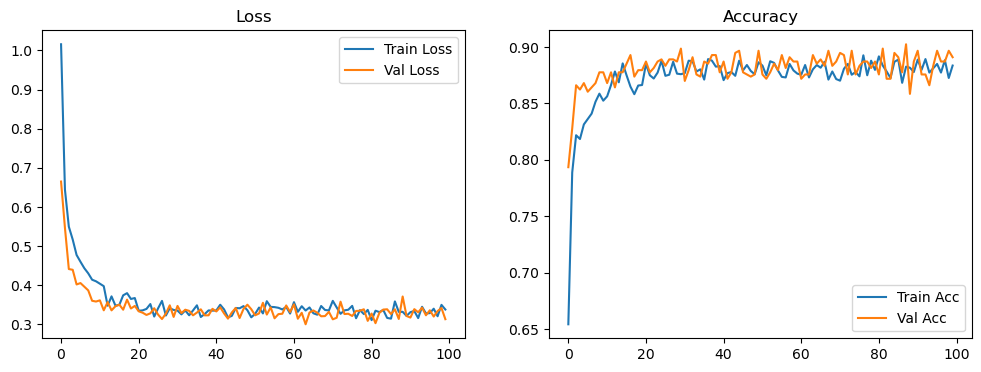

In [10]:
num_epochs = 100
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(num_epochs):
    # Train
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = correct / total
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)  # Adjust LR
    
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [11]:
# Predictions and report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")

model_path = '/home/rifat-cou/Documents/Project/Models'
EfficientNetB0 = os.path.join(model_path, 'EfficientNetB0')
os.makedirs(EfficientNetB0, exist_ok=True) 

# Save model
torch.save(model.state_dict(), os.path.join(EfficientNetB0, 'efficientnet_b0_100_skin_lesion.pth'))

              precision    recall  f1-score   support

   Chikenpox       0.81      0.80      0.80        98
      Cowpox       0.96      0.92      0.94        95
     Measles       0.96      0.98      0.97        99
   MonkeyPox       0.83      0.79      0.81       121
      Normal       0.90      0.97      0.93       110

    accuracy                           0.89       523
   macro avg       0.89      0.89      0.89       523
weighted avg       0.89      0.89      0.89       523

Accuracy: 0.8891
